In [1]:
# -*- coding: utf-8 -*-
#  Copyright 2026 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by:    Margaret Duff, STFC - UKRI

# Sandstone 2D parallel-beam data reconstruction demo



In [2]:
datapath = "/mnt/share-private/notebooks/Sandstone"

In [3]:
# Import all CIL components needed
from cil.framework import ImageData, ImageGeometry
from cil.framework import AcquisitionGeometry, AcquisitionData

# CIL Processors
from cil.processors import CentreOfRotationCorrector, Slicer, TransmissionAbsorptionConverter, Normaliser, Padder

# CIL display tools
from cil.utilities.display import show2D, show_geometry

# CIL FBP
from cil.recon import FBP

# From CIL ASTRA plugin
from cil.plugins.astra import ProjectionOperator

# All external imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os

Switch on printing of more info in some of the methods including `CentreOfRotationCorrector`:

In [4]:
import logging
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

The data contains selected 2D projections, flat and dark fields, as well as complete 2D sinograms for 4 horizontal slices. We first load and display a couple of projections

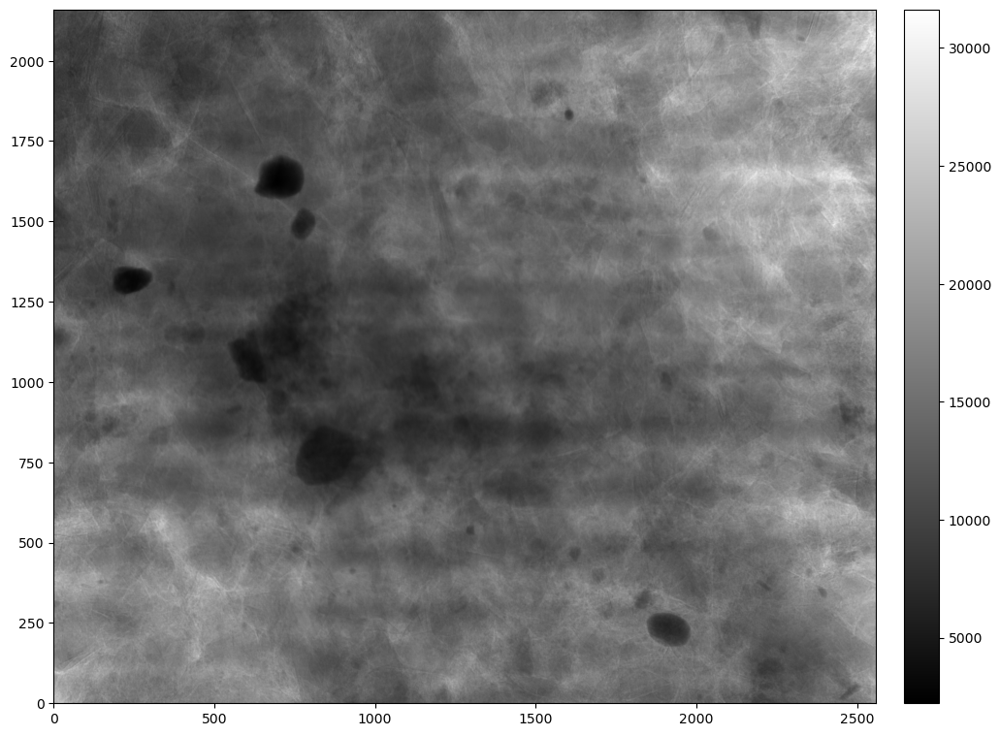

In [5]:
proj1 = plt.imread(os.path.join(datapath,"proj","BBii_0131.tif"))
show2D(proj1)

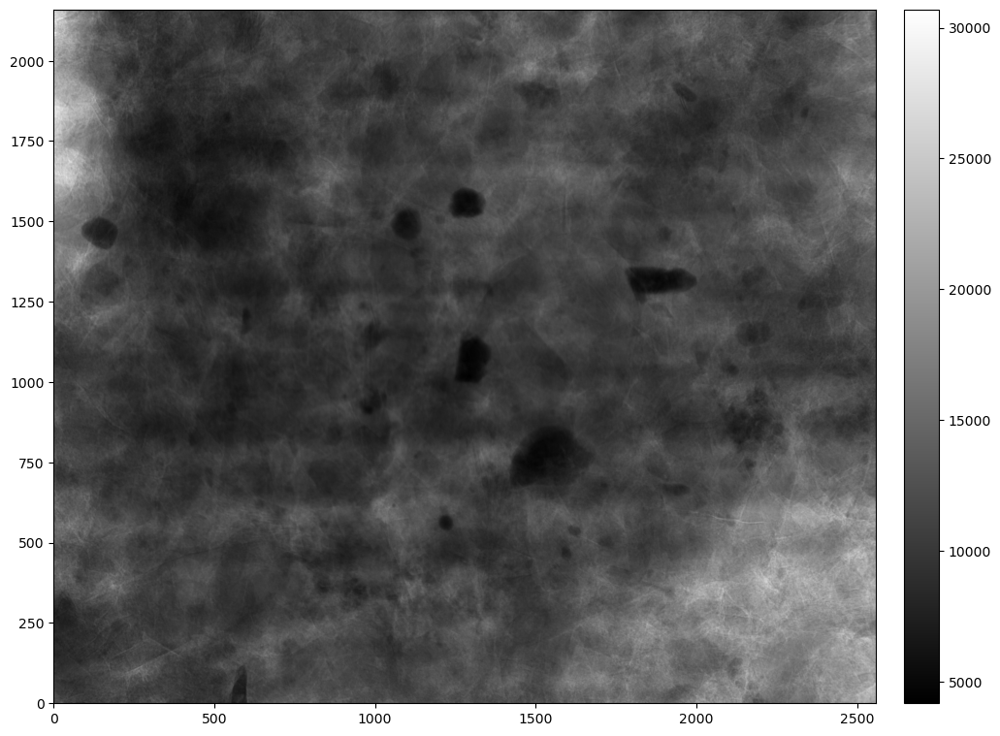

In [6]:
proj2 = plt.imread(os.path.join(datapath,"proj","BBii_0931.tif"))
show2D(proj2)

We also load and display a flat field (image taken before projections with source on, and sample out):

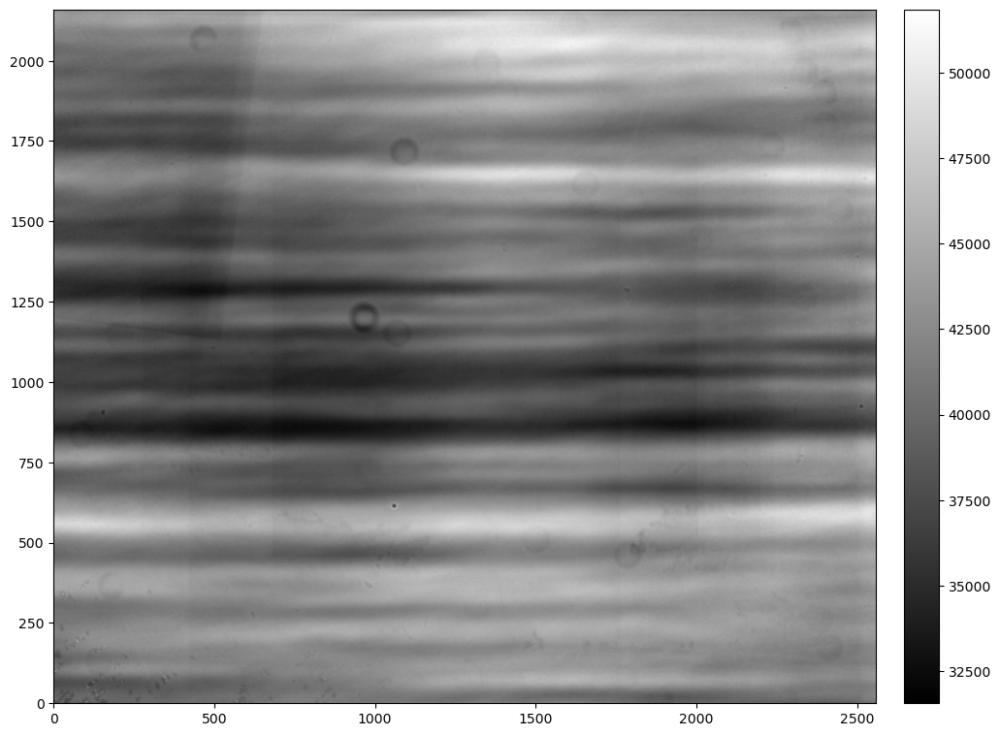

In [7]:
flat1 = plt.imread(os.path.join(datapath,"proj","BBii_0031.tif"))
show2D(flat1)

We also load and display a dark field (image taken before projections and flat with source off, and sample out, to capture any background counts):

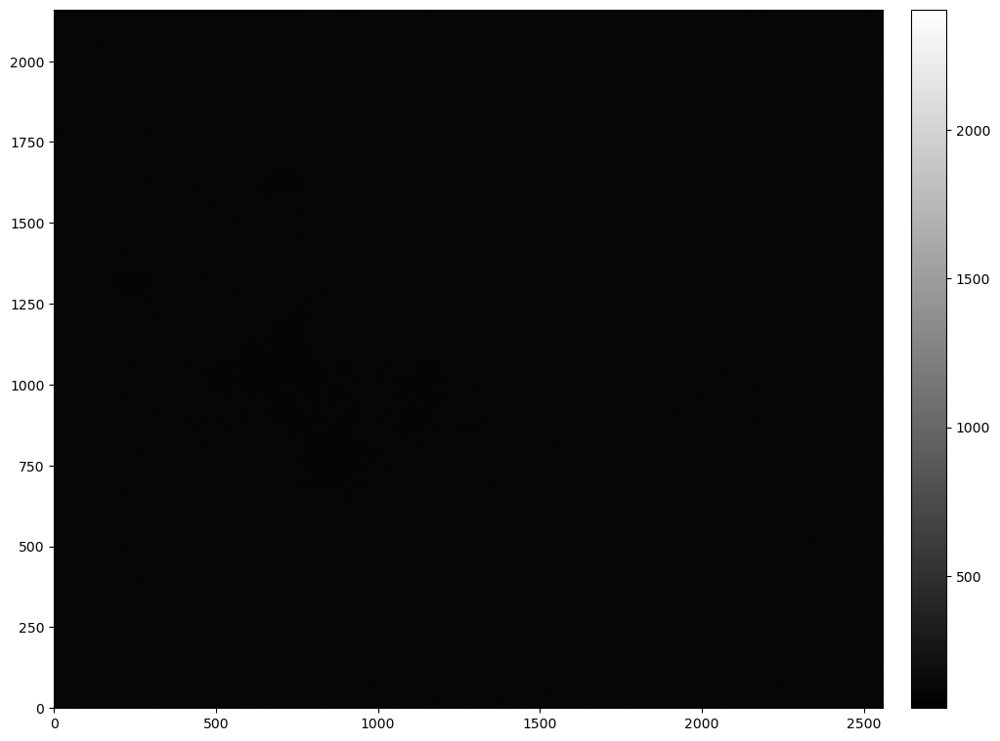

In [8]:
dark1 = plt.imread(os.path.join(datapath,"proj","BBii_0002.tif"))
show2D(dark1)

Projections have 2160 rows and 2560 columns as seen by:

In [9]:
proj1.shape

(2160, 2560)

For convenience sinograms for four selected slices have been extracted from the full 1500 projections and are provided as mat-files. We choose one and load it:

Load demo data set and display the first raw projection

In [10]:
filename = "slice_0270_data.mat"
all_data = scipy.io.loadmat(os.path.join(datapath,filename))


The data contains projections, flats and darks for the selected slice. There are 1500 projections of size 2560 pixels:

In [11]:
projs = all_data['X_proj'].astype(np.float32)
projs.shape

(2560, 1500)

There are 200 flats (100 taken before, and 100 taken after the projections):

In [12]:
flats = all_data['X_flat'].astype(np.float32)
flats.shape

(2560, 200)

There are 30 darks taken at the beginning of the experiment:

In [13]:
darks = all_data['X_dark'].astype(np.float32)
darks.shape

(2560, 30)

The data provided also contains the reconstruction produced at the synchrotron where the data was acquired. We load and display it to see what kind of image we aim to reconstruct:

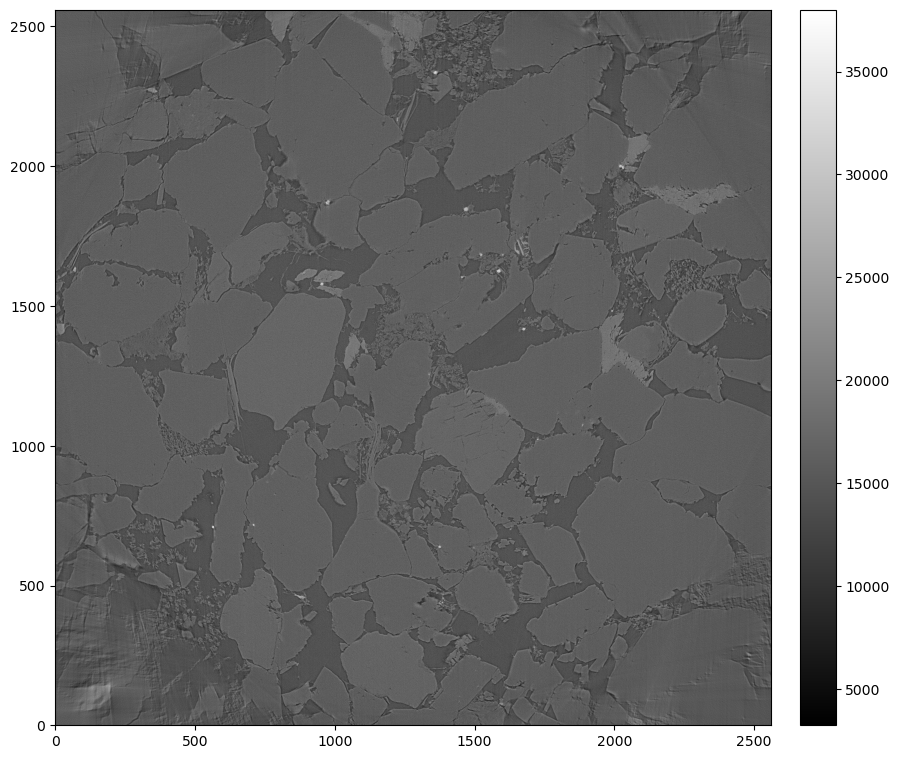

In [14]:
vendor_recon = plt.imread(os.path.join(datapath,"recon","BBii_0270.rec.16bit.tif"))
show2D(np.rot90(vendor_recon))

OK, we have now taken a look at the data and are ready to start producing our own reconstruction. We need to go through a number of steps to get there. 

As a first step toward reconstructing the data, we specify the CIL `AcquisitionGeometry` for a 2D parallel-beam geometry with 1500 projections over 0 to 180 degrees each consisting of 2560 detector pixels.

In [15]:
ag = AcquisitionGeometry.create_Parallel2D()  \
         .set_panel(num_pixels=(2560))        \
         .set_angles(angles=np.linspace(0,180,1500,endpoint=False))

We can illustrate the geometry specified:

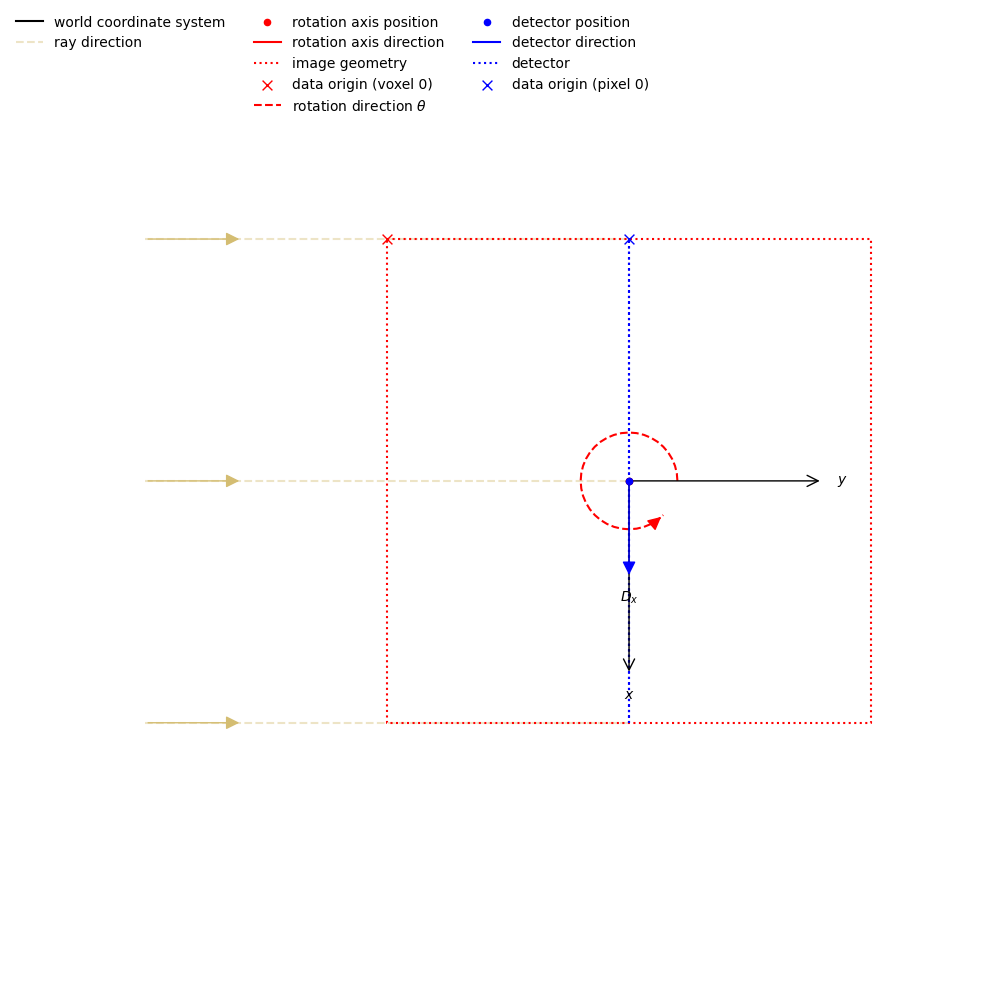

In [16]:
show_geometry(ag)

To create the CIL data structure `AcquisitionData` holding the data we check again the size of the projections

In [17]:
projs.shape

(2560, 1500)

so along the first dimension are the horizontal detector pixels and along the second the projections/angles. We then tell CIL which axes are which:

In [18]:
ag.set_labels(['horizontal','angle'])
print(ag.dimension_labels)

(<AcquisitionDimension.HORIZONTAL: 'horizontal'>, <AcquisitionDimension.ANGLE: 'angle'>)


Now we create an `AcquisitionData` holding the projections and the geometry. We link the `projs` numpy array to the `AcquisitionData` without creating an additional copy.

In [19]:
data = AcquisitionData(projs, geometry=ag, deep_copy=False)

We can take a look with the CIL `show2D` display function:

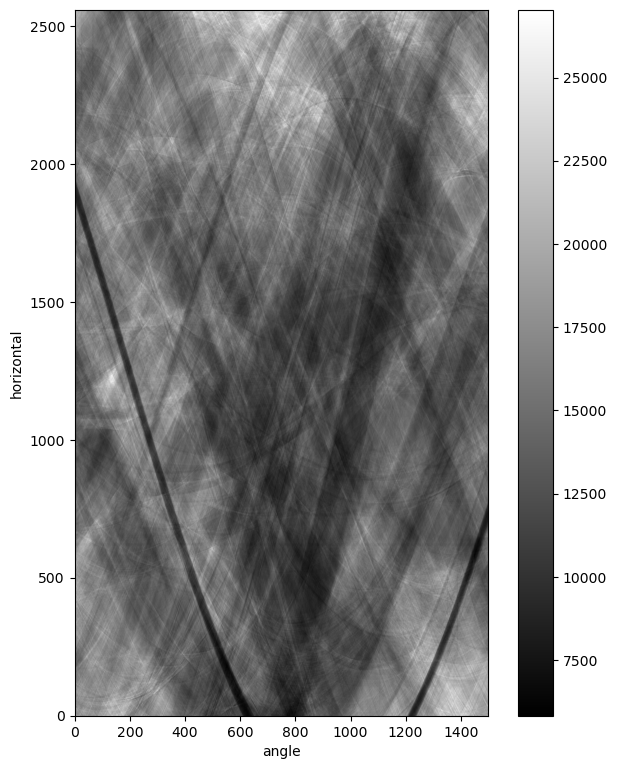

In [20]:
show2D(data)

Let us try reconstructing straight from the raw projections. First we need to make sure the data matches the order expected by the ASTRA-Toolbox plugin. We use `reorder('astra')` to check and reorder the data if required.

In [21]:
data.reorder('astra')

Now we must specify the `ImageGeometry` we want for the reconstruction grid, here we choose the default which can be generated from the `AcquisitionGeometry`:

In [22]:
ig = ag.get_ImageGeometry()

We set up and run the FBP reconstructor with our dataset and specify the backend to use:

In [23]:
rec1 = FBP(data, ig, backend='astra').run()

FBP recon

Input Data:
	angle: 1500
	horizontal: 2560

Reconstruction Volume:
	horizontal_y: 2560
	horizontal_x: 2560

Reconstruction Options:
	Backend: astra
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 13
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



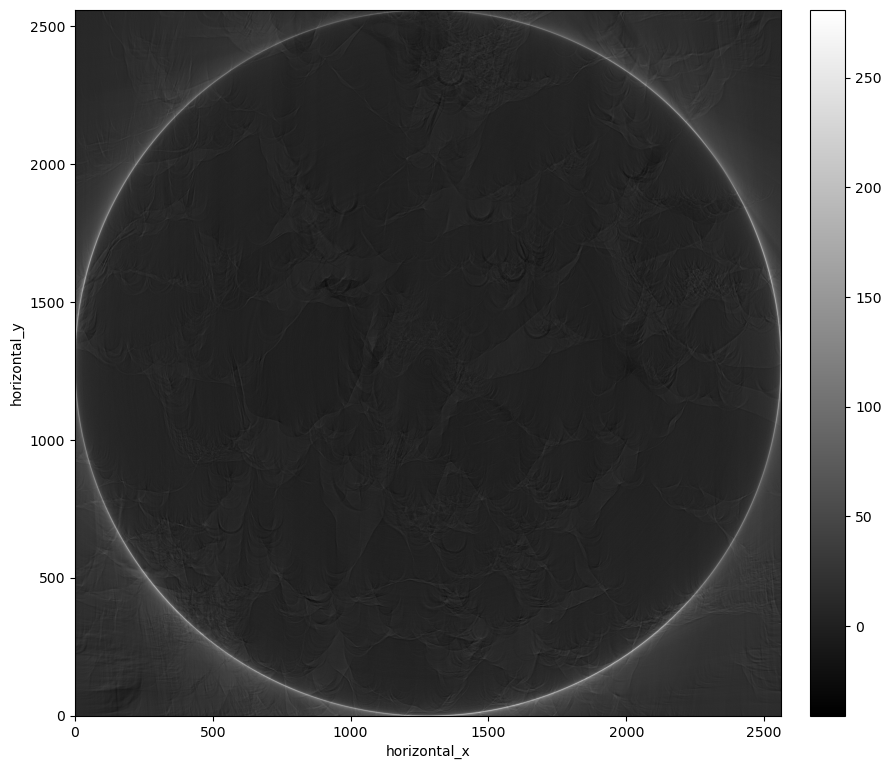

In [24]:
show2D(rec1)

On close inspection we see some of the right features but distorted and wrong colours. The first thing we are missing is to normalise the data, i.e., apply flat and dark field correction. This is achieved by the CIL `Normaliser` processor and we simply use the mean over the flat and dark images respectively:

In [25]:
data2 = Normaliser(flat_field=flats.mean(axis=1),
                   dark_field=darks.mean(axis=1)
                  )(data)

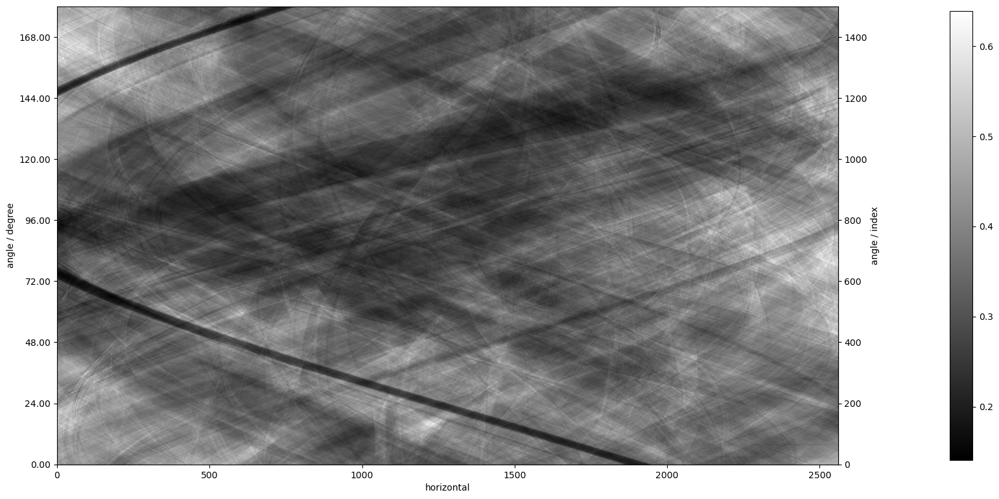

In [26]:
show2D(data2)

Compared to the previous sinogram of the raw projections, we see on the colourbar that the range is now within 0 to 1 as is what we need. We try reconstructing again:

In [27]:
rec2 = FBP(data2, ig, backend='astra').run()

FBP recon

Input Data:
	angle: 1500
	horizontal: 2560

Reconstruction Volume:
	horizontal_y: 2560
	horizontal_x: 2560

Reconstruction Options:
	Backend: astra
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 13
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



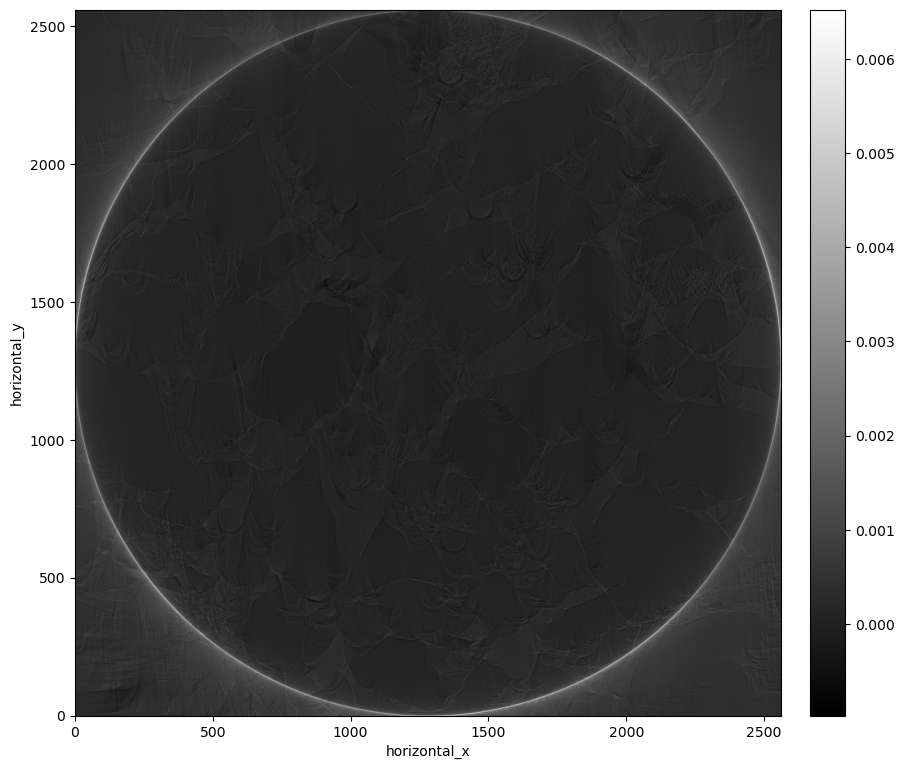

In [28]:
show2D(rec2)

It looks that same, only has the range change as seen on the colourbar. We realise that we need to apply the negative logarithm according to the Lambert-Beer law, which can be done manually or using a CIL `Processor`, which will prevent outliers and zeros from causing trouble:

In [29]:
data3 = TransmissionAbsorptionConverter()(data2)

INFO:cil.processors.TransmissionAbsorptionConverter:
 Current min_intensity = 0.0: output may contain NaN or inf. Ensure your data only contains positive values or set min_intensity to a small positive value.


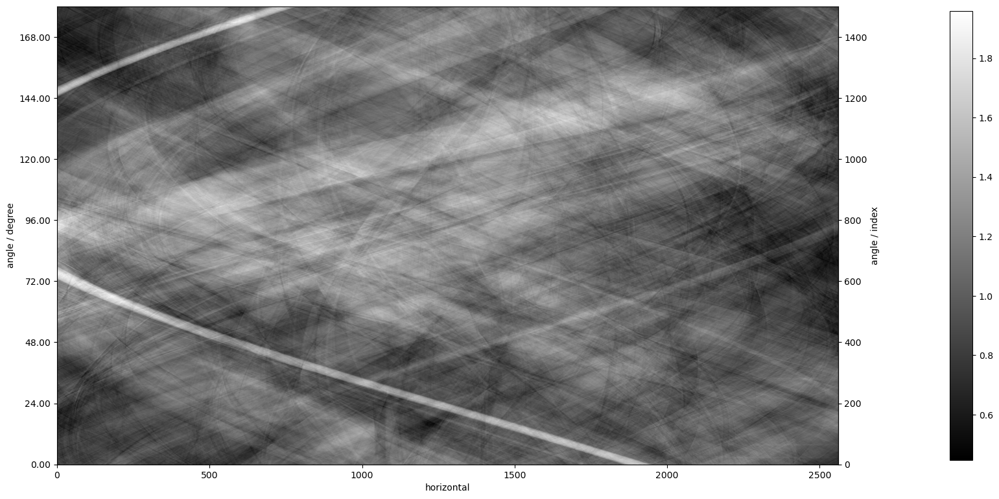

In [30]:
show2D(data3)

We see the data has been transformed so the big sine band shows up white instead of dark as before. We attempt reconstructing:

In [31]:
rec3 = FBP(data3, ig, backend='astra').run()

FBP recon

Input Data:
	angle: 1500
	horizontal: 2560

Reconstruction Volume:
	horizontal_y: 2560
	horizontal_x: 2560

Reconstruction Options:
	Backend: astra
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 13
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



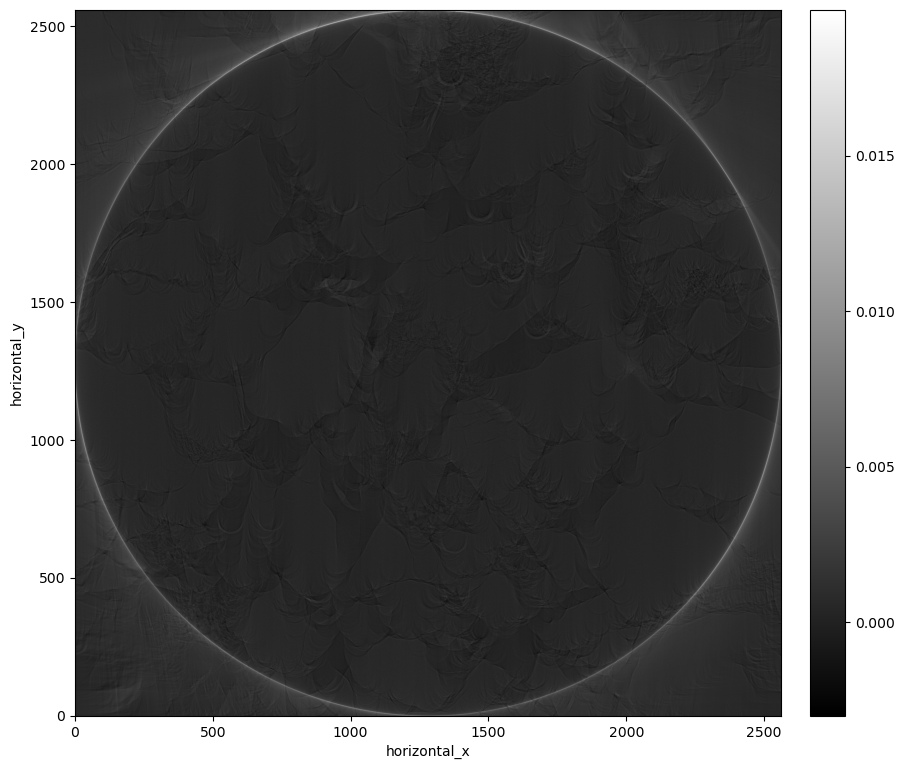

In [32]:
show2D(rec3)

The colours have flipped now, so it is a step forward, but there is a big white ring. This is because the data is region-of-interest, i.e., the sample was larger than the field of view, so projections are truncated (i.e. do not have air on both sides as also seen in the sinograms). A simple way to compensate for this is to extend or pad the data on both sides of the projections. Using the CIL `Padder` processor we can for example pad by the left and rightmost pixel values, and we can play with the amount of padding required to push the ring out of the reconstruction. A `padsize` of about 600 is required:

In [33]:
padsize = 600
data4 = Padder.edge(pad_width={'horizontal': padsize})(data3)

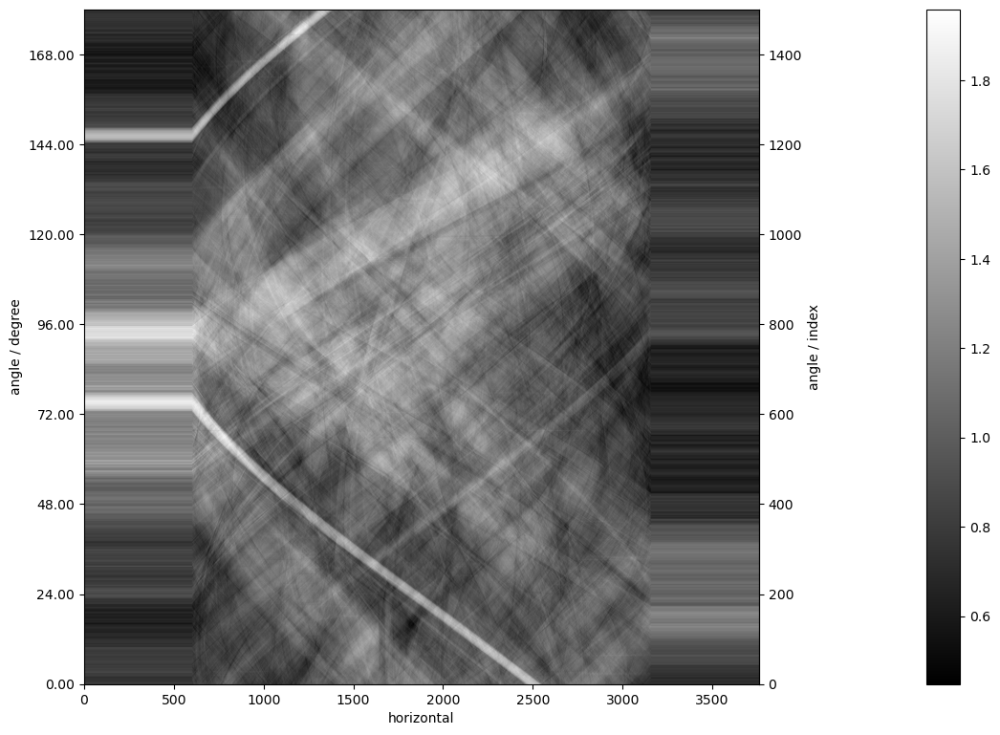

In [34]:
show2D(data4)

We see the data has been extended left and right. In effect the sinogram is now larger, so we need to create a new FBP reconstructor configured for the new padded data. We keep the reconstruction volume (defined by our image geometry) the same as before as we are not interested in the extended region.

In [35]:
rec4 = FBP(data4, ig, backend='astra').run()

FBP recon

Input Data:
	angle: 1500
	horizontal: 3760

Reconstruction Volume:
	horizontal_y: 2560
	horizontal_x: 2560

Reconstruction Options:
	Backend: astra
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 13
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



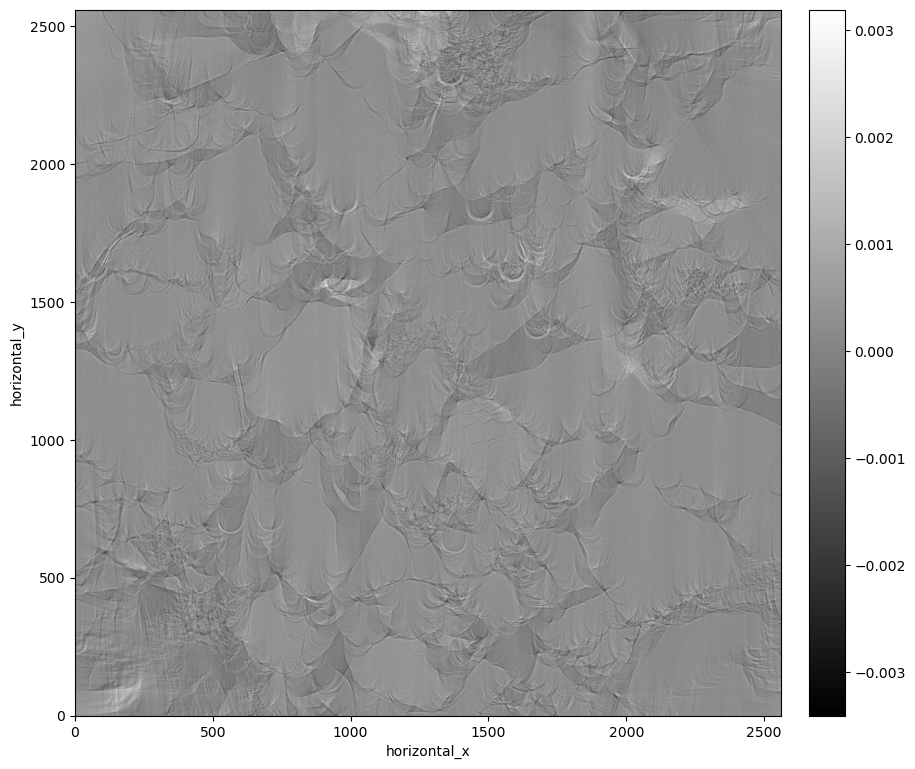

In [36]:
show2D(rec4)

With `padsize=600` we see the region-of-interest ring has been successfully moved out and the sample features are more clearly seen. However there are still artifacts in the form of U-shaped stripes. These are centre-of-rotation artifacts caused by the sample not being perfectly centered during scanning. The log file of the dataset provides the centre value that was determined at the synchrotron. Here we use a CIL `Processor` to determine the offset and update the geometry. It works by doing FBP reconstructions for a range of offset parameters, evaluates a quality metric based on image sharpness and searches for the best offset. This technique is designed for use when you have 360 degrees of data, but can be applied to 180 degrees but will be very sample dependent.

In [37]:
data5 = CentreOfRotationCorrector.image_sharpness(backend='astra', search_range=100, tolerance=0.1)(data4)

INFO:cil.processors.CofR_image_sharpness:evaluated 11 points
INFO:cil.processors.CofR_image_sharpness:evaluated 11 points
INFO:cil.processors.CofR_image_sharpness:Centre of rotation correction found using image_sharpness
INFO:cil.processors.CofR_image_sharpness:backend FBP/FDK astra
INFO:cil.processors.CofR_image_sharpness:Calculated from slice: centre
INFO:cil.processors.CofR_image_sharpness:Centre of rotation shift = 44.489077 pixels
INFO:cil.processors.CofR_image_sharpness:Centre of rotation shift = 44.489077 units at the object
INFO:cil.processors.CofR_image_sharpness:Return new dataset with centred geometry


We can compute the centre of rotation from a CIL geometry. The argument `distance_units` allows you to define the units of the returned value. Here we specify pixels.

In [38]:
data5.geometry.get_centre_of_rotation(distance_units='pixels')

{'offset': (44.489076769386344, 'pixels'), 'angle': (0.0, 'radian')}

In [39]:
rec5 = FBP(data5, ig, backend='astra').run()

FBP recon

Input Data:
	angle: 1500
	horizontal: 3760

Reconstruction Volume:
	horizontal_y: 2560
	horizontal_x: 2560

Reconstruction Options:
	Backend: astra
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 13
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



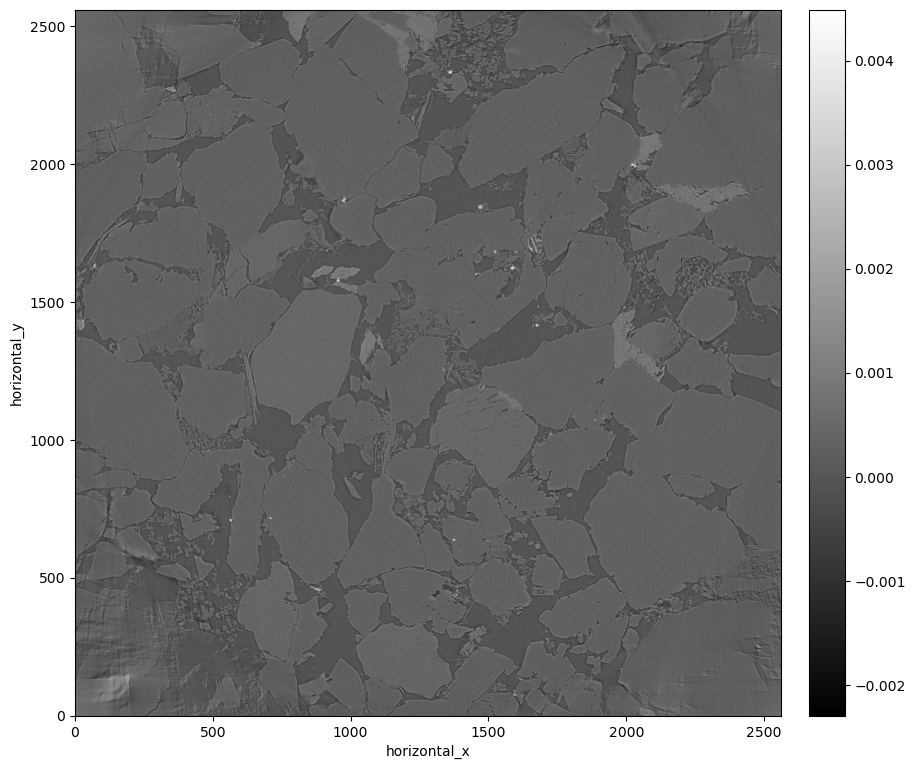

In [40]:
show2D(rec5)

This reproduces the result from the synchrotron quite well, we show it again here for comparison:

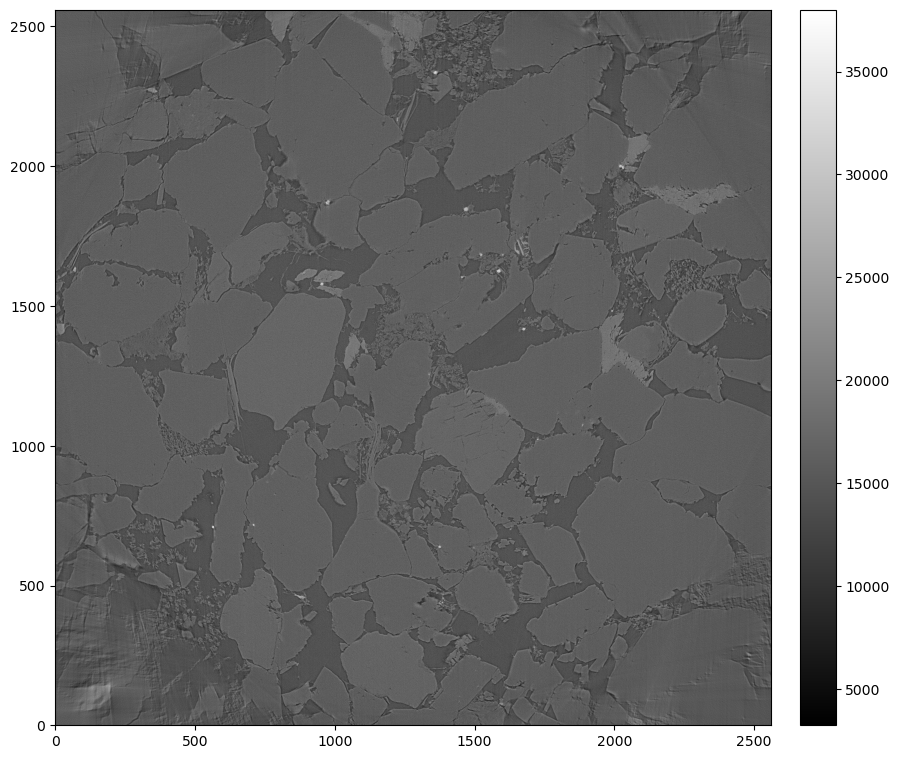

In [41]:
show2D(np.rot90(vendor_recon))

FBP recon

Input Data:
	angle: 1500
	horizontal: 940

Reconstruction Volume:
	horizontal_y: 940
	horizontal_x: 940

Reconstruction Options:
	Backend: astra
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



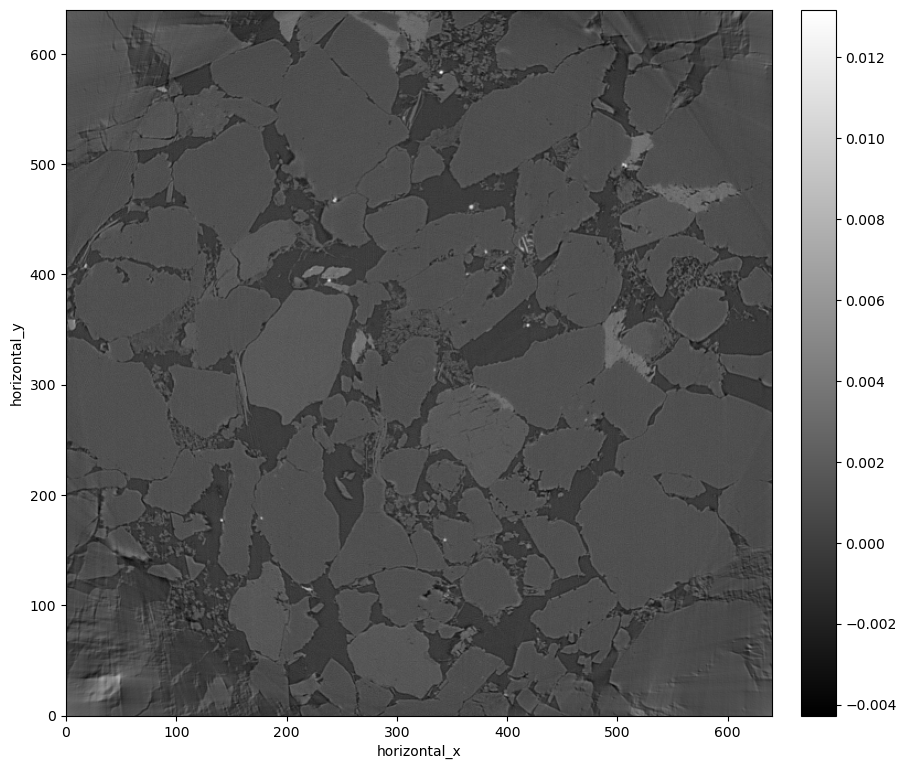

In [42]:
from cil.processors import Binner
roi = {'horizontal': (None, None, 4)}
processor = Binner(roi)
processor.set_input(data5)
data_binned = processor.get_output()

ig_binned= data_binned.geometry.get_ImageGeometry()

rec_binned = FBP(data_binned, ig_binned, backend='astra').run()

roi_recon = { 'horizontal_x':(150, -150, None), 'horizontal_y':(150, -150, None)}
processor_recon = Slicer(roi_recon)
processor_recon.set_input(rec_binned)
rec_binned = processor_recon.get_output()

show2D(rec_binned)

In [43]:
import deepinv as dinv
from pathlib import Path
import torch
from deepinv.models import DnCNN
from deepinv.optim.data_fidelity import L2
from deepinv.optim.prior import PnP

from deepinv.utils.plotting import plot, plot_curves

torch.manual_seed(0)
device = 'cuda'



In [44]:

from __future__ import annotations
from typing import Iterable
from types import MappingProxyType
from warnings import warn
import math
from deepinv.physics.forward import LinearPhysics, adjoint_function
from deepinv.physics.functional import (
    Radon,
    IRadon,
    RampFilter,
    ApplyRadon,
    XrayTransform,
)
from deepinv.physics.functional.astra import (
    AutogradTransform,
    create_projection_geometry,
    create_object_geometry,
)
from deepinv.utils.decorators import _deprecated_alias

class TomographyWithAstra(LinearPhysics):
    r"""Computed Tomography operator with `astra-toolbox <https://astra-toolbox.com/>`_ backend.
    It is more memory efficient than the :class:`deepinv.physics.Tomography` operator and support 3D geometries.
    See documentation of :class:`deepinv.physics.functional.XrayTransform` for more
    information on the ``astra`` wrapper.

    Mathematically, it is described as a ray transform
    :math:`A` which linearly integrates an object :math:`x` along straight
    lines

    .. math::
        y = \forw{x}

    where :math:`y` is the set of line integrals, called sinogram in 2D, or
    radiographs in 3D. An object is typically scanned using a surrounding circular
    trajectory. Given different acquisition systems, the lines along which
    the integrals are computed follow different geometries:

    * parallel. (2D and 3D)
        Per view, all rays intersecting the object are parallel. In 2D, all rays live on the same plane, perpendicular
        to the axis of rotation.
    * fanbeam. (2D)
        Per view, all rays come from a single source and intersect the object at a certain angle. The detector consists of a 1d line of cells. Similar to
        the 2D "parallel", all rays live on the same plane, perpendicular to the axis of rotation.
    * conebeam. (3D)
        Per view, all rays come from a single source. The detector consists of a 2D grid of cells. Apart from the central plane, the set of rays coming onto
        a line of cells live on a tilted plane.

    .. note::

        The pseudo-inverse is computed using the filtered back-projection
        algorithm with a Ramp filter, and its equivalent for conebeam 3D, the
        Feldkamp-Davis-Kress algorithm. This is not the exact linear pseudo-inverse
        of the Ray Transform, but it is a good approximation which is robust to noise.

    .. note::

        In the default configuration, reconstruction cells and detector cells are
        set to have isotropic unit lengths. The geometry is set to 2D parallel
        and matches the default configuration of the :class:`deepinv.physics.Tomography` operator with
        ``circle=False``.

    .. warning::

        By default, ``normalize`` is set to ``True`` if not specified. Initializing the operator without specifying the normalization behavior will issue a warning. Note that normalizing the operator affects the reconstruction dynamics, which may not always be suitable for real-world applications.

    .. warning::

        Due to computational efficiency reasons, the projector and backprojector
        implemented in ``astra`` are not matched. The projector is typically ray-driven,
        while the backprojector is pixel-driven. The adjoint of the forward Ray Transform
        is approximated by rescaling the backprojector.

    .. warning::

        The :class:`deepinv.physics.functional.XrayTransform` used in :class:`deepinv.physics.TomographyWithAstra` sequentially processes batch elements, which can make the 2D parallel beam operator significantly slower than its native torch counterpart with :class:`deepinv.physics.Tomography` (though still more memory-efficient).

    :param tuple[int, ...] img_size: Shape of the object grid, either a 2 or 3-element tuple, for respectively 2D or 3D.
    :param int angles: Number of angular positions sampled uniformly in ``angular_range`` or a Tensor containing angular positions in degrees. (default: 180)
    :param int | tuple[int, ...], None n_detector_pixels: In 2D, specify an integer for a single line of detector cells. In 3D, specify a 2-element tuple for (row,col) shape of the detector. (default: None)
    :param tuple[float, float] angular_range: Angular range, defaults to ``(0, 180)``.
    :param float | tuple[float, float] detector_spacing: In 2D the width of a detector cell. In 3D a 2-element tuple specifying the (vertical, horizontal) dimensions of a detector cell. (default: 1.0)
    :param float | tuple[float, ...] pixel_spacing: In 2D, the (x,y) dimensions of a pixel in the reconstructed image. In 3D, the (x,y,z) dimensions of a voxel. Scalar value is interpreted as the same dimension along all axes (default: 1.0)
    :param tuple[float, ...], None bounding_box: Axis-aligned bounding-box of the reconstruction area [min_x, max_x, min_y, max_y, ...]. Optional argument, if specified, overrides argument ``object_spacing``. (default: None)
    :param str geometry_type: The type of geometry among ``'parallel'``, ``'fanbeam'`` in 2D and ``'parallel'`` and ``'conebeam'`` in 3D. (default: ``'parallel'``)
    :param dict[str, float] geometry_parameters: Contains extra parameters specific to certain geometries. When ``geometry_type='fanbeam'`` or  ``'conebeam'``, the dictionary should contains the keys

        - ``"source_radius"``: the distance between the x-ray source and the rotation axis, denoted :math:`D_{s0}`, (default: 80.),

        - ``"detector_radius"``: the distance between the x-ray detector and the rotation axis, denoted :math:`D_{0d}`. (default: 20.)

    :param torch.Tensor, None geometry_vectors: Alternative way to describe a 3D geometry. It is a torch.Tensor of shape [num_angles, 12], where for each angular position of index ``i`` the row consists of a vector of size (12,) with

        - ``(sx, sy, sz)`
        : the position of the source,

        - ``(dx, dy, dz)``: the center of the detector,

        - ``(ux, uy, uz)``: the horizontal unit vector of the detector,

        - ``(vx, vy, vz)``: the vertical unit vector of the detector.

        When specified, ``geometry_vectors`` overrides ``detector_spacing``, ``angles`` and ``geometry_parameters``. It is particularly useful to build the geometry for the `Walnut-CBCT dataset <https://zenodo.org/records/2686726>`_, where the acquisition parameters are provided via such vectors.
    :param bool normalize: If ``True`` :func:`A` and :func:`A_adjoint` are normalized so that the operator has unit norm. (default: ``True``)
    :param torch.device | str device: The operator only supports CUDA computation. (default: ``torch.device('cuda')``)

    |sep|

    :Examples:

        Tomography operator with a 2D ``'fanbeam'`` geometry, 10 uniformly sampled angles in ``[0, 360]``, a detector line of 5 cells with length 2., a source-radius of 20.0 and a detector_radius of 20.0 for 5x5 image:

        .. doctest::
           :skipif: astra is None or not cuda_available

            >>> from deepinv.physics import TomographyWithAstra
            >>> x = torch.randn(1, 1, 5, 5, device='cuda') # Define random 5x5 image
            >>> physics = TomographyWithAstra(
            ...        img_size=(5,5),
            ...        angles=10,
            ...        angular_range=(0, 360),
            ...        n_detector_pixels=5,
            ...        detector_spacing=2.0,
            ...        geometry_type='fanbeam',
            ...        geometry_parameters={
            ...            'source_radius': 20.,
            ...            'detector_radius': 20.
            ...        },
            ...        normalize=False
            ...    )
            >>> sinogram = physics(x)
            >>> print(sinogram.shape)
            torch.Size([1, 1, 10, 5])

        Tomography operator with a 3D ``'conebeam'`` geometry, 10 uniformly sampled angles in ``[0, 360]``, a detector grid of 5x5 cells of size (2.,2.), a source-radius of 20.0 and a detector_radius of 20.0 for a 5x5x5 volume:

        .. doctest::
           :skipif: astra is None or not cuda_available

            >>> x = torch.randn(1, 1, 5, 5, 5, device='cuda')  # Define random 5x5x5 volume
            >>> angles = torch.linspace(0, 360, steps=4)[:-1]
            >>> physics = TomographyWithAstra(
            ...        img_size=(5,5,5),
            ...        angles = angles,
            ...        n_detector_pixels=(5,5),
            ...        pixel_spacing=(1.0,1.0,1.0),
            ...        detector_spacing=(2.0,2.0),
            ...        geometry_type='conebeam',
            ...        geometry_parameters={
            ...            'source_radius': 20.,
            ...            'detector_radius': 20.
            ...       },
            ...        normalize=False
            ...    )
            >>> sinogram = physics(x)
            >>> print(sinogram.shape)
            torch.Size([1, 1, 5, 3, 5])


    .. note::

        This class requires the ``astra-toolbox`` package to be installed. Install with ``pip install astra-toolbox``.
    """

    @_deprecated_alias(
        num_angles="angles",
        num_detectors="n_detector_pixels",
        object_spacing="pixel_spacing",
    )
    def __init__(
        self,
        img_size: tuple[int, ...] | None = None,
        angles: int | torch.Tensor = 180,
        n_detector_pixels: int | tuple[int, ...] | None = None,
        angular_range: tuple[float, float] = (0, 180),
        detector_spacing: float | tuple[float, float] = 1.0,
        pixel_spacing: float | tuple[float, ...] = 1.0,
        bounding_box: tuple[float, ...] | None = None,
        geometry_type: str = "parallel",
        geometry_parameters: dict[str, float] = MappingProxyType(
            {
                "source_radius": 80.0,
                "detector_radius": 20.0,
            }
        ),
        geometry_vectors: torch.Tensor | None = None,
        normalize: bool | None = None,
        device: torch.device | str = torch.device("cuda"),
        astra_object_geom: Any| None = None,
        astra_projection_geom: Any | None = None,
        is_2d: bool | None = None,
        **kwargs,
    ):
        super().__init__(device=device, **kwargs)
        
        if astra_object_geom is not None or astra_projection_geom is not None:
            if astra_object_geom is None or astra_projection_geom is None:
                raise ValueError("Both `astra_object_geom` and `astra_projection_geom` must be specified together.")
            if is_2d is None:
                raise ValueError("When `astra_object_geom` and `astra_projection_geom` are specified, `is_2d` must also be specified to indicate whether the geometry is 2D or 3D.")
            self.object_geometry = astra_object_geom
            self.projection_geometry = astra_projection_geom
            self.is_2d = is_2d
            self.img_size = (self.object_geometry['GridRowCount'], self.object_geometry['GridColCount']) if self.is_2d else (self.object_geometry['GridRowCount'], self.object_geometry['GridColCount'], self.object_geometry['GridSliceCount']) # TODO: Check this for 3D 

        else:
            if self.img_size is None:
                raise ValueError("`img_size` must be specified when `astra_object_geom` and `astra_projection_geom` are not provided.")

            if isinstance(geometry_parameters, MappingProxyType):
                geometry_parameters = geometry_parameters.copy()

            assert len(img_size) in (
                2,
                3,
            ), f"len(img_size) is {len(img_size)}, must be either 2 or 3 (for 2D and 3D respectively)"

            if torch.device(device).type != "cuda":
                warn(
                    f"TomographyWithAstra only supports CUDA Tensors and CUDA operations, got device={device}",
                    RuntimeWarning,
                )

            self.img_size = img_size
            self.is_2d = len(img_size) == 2
            self.n_detector_pixels = (
                math.ceil(math.sqrt(2) * img_size[0])
                if n_detector_pixels is None
                else n_detector_pixels
            )
            self.geometry_type = geometry_type

            if isinstance(angles, int):
                angles = torch.linspace(*angular_range, steps=angles + 1)[:-1]

            self.object_geometry = create_object_geometry(
                *img_size,
                bounding_box=bounding_box,
                pixel_spacing=pixel_spacing,
                is_2d=self.is_2d,
            )

            self.projection_geometry = create_projection_geometry(
                geometry_type=geometry_type,
                detector_spacing=detector_spacing,
                n_detector_pixels=self.n_detector_pixels,
                angles=angles,
                is_2d=self.is_2d,
                geometry_parameters=geometry_parameters,
                geometry_vectors=geometry_vectors,
            )

        self.xray_transform = XrayTransform(
            object_geometry=self.object_geometry,
            projection_geometry=self.projection_geometry,
            is_2d=self.is_2d,
        )

        self.filter = RampFilter(dtype=torch.float32)

        if normalize is None:
            warn(
                "The default value of `normalize` is not specified and will be automatically set to `True`. Set `normalize` explicitly to `True` or `False` to avoid this warning.",
            )
            normalize = True

        self.normalize = False
        if normalize:
            self.operator_norm = self.compute_norm(
                torch.randn(
                    self.img_size,
                    generator=torch.Generator(device).manual_seed(0),
                    device=device,
                )[None, None],
                squared=False,
            )
            self.normalize = True

        self.to(device)

    @property
    def measurement_shape(self) -> tuple[int, ...]:
        if self.is_2d:
            return self.xray_transform.range_shape[1:]
        else:
            return self.xray_transform.range_shape

    @property
    def num_angles(self) -> int:
        return self.xray_transform.range_shape[1]



    def fbp_weighting(self, sinogram: torch.Tensor) -> torch.Tensor:
        r"""Scales the computation by the inverse number of views and
        object-to-detector cell ratio.

        In conebeam 3D, compute FDK weights to correct inflated distances due to
        tilted rays. Given coordinate :math:`(x,y)`  of a detector cell, the corresponding
        weight is :math:`\omega(x,y) = \frac{D_{s0}}{\sqrt{D_{sd}^2 + x^2 + y^2}}`.

        :param torch.Tensor sinogram: Sinogram of shape [B,C,...,A,N].
        :return: Weighted sinogram.
        """
        import astra

        sinogram_scaled = torch.clone(sinogram)
        is_3d = len(sinogram.shape) == 5

        if self.geometry_type == "conebeam" and is_3d:
            # dimensions (V,N) are (col,row) of the 2D detector
            # A is the number of angles
            B, C, V, A, N = sinogram.shape

            # vecs.shape = (num_angles, 12) with
            # (sx, sy, sz, dx, dy, dz, ux, uy, uz, vx, vy, vz) coordinates
            # - (sx, sy, sz) is the position of the source
            # - (dx, dy, dz) is the center of the detector
            # - (ux, uy, uz) is the horizontal unit vector of the detector
            # - (vx, vy, vz) is the vertical unit vector of the detector
            vecs = torch.from_numpy(
                astra.geom_2vec(self.projection_geometry)["Vectors"]
            )

            source_object_distance = torch.linalg.norm(
                vecs[:, [0, 1, 2]], axis=1, keepdims=False
            )

            v_range = torch.arange(V, dtype=torch.float64) - (V - 1) / 2
            u_range = torch.arange(N, dtype=torch.float64) - (N - 1) / 2

            v_grid, u_grid = torch.meshgrid(v_range, u_range, indexing="ij")
            weights = torch.ones((V, N), dtype=torch.float, device=sinogram.device)
            for i in range(A):
                source_position = vecs[i, [0, 1, 2]]
                detector_center_position = vecs[i, [3, 4, 5]]

                u_basis = vecs[i, [6, 7, 8]]
                v_basis = vecs[i, [9, 10, 11]]

                detector_pixel_positions = (
                    u_grid[..., None] * u_basis
                    + v_grid[..., None] * v_basis
                    + detector_center_position
                )

                pixel_ray_lengths = torch.linalg.norm(
                    detector_pixel_positions - source_position, dim=-1
                )

                weights[:] = source_object_distance[i] / pixel_ray_lengths

                sinogram_scaled[:, :, :, i, :] *= weights

        sinogram_scaled *= self.xray_transform.detector_cell_v_length
        sinogram_scaled /= self.xray_transform.object_cell_volume
        sinogram_scaled *= torch.pi / (2 * self.num_angles)

        return sinogram_scaled





    def A(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        """Forward projection.

        :param torch.Tensor x: input of shape [B,C,...,H,W]
        :return: projection of shape [B,C,...,A,N]
        """
        out = AutogradTransform.apply(x, self.xray_transform)
        if self.normalize:
            out /= self.operator_norm

        return out



    def fbp(self, y: torch.Tensor, **kwargs) -> torch.Tensor:
        filtered_y = self.filter(y, dim=-1)
        out = self.A_adjoint(self.fbp_weighting(filtered_y))
        if self.normalize:
            out *= self.operator_norm**2

        return out



    def A_dagger(self, y: torch.Tensor, fbp: bool = False, **kwargs) -> torch.Tensor:
        r"""
        Computes the solution in :math:`x` to :math:`y = Ax` using a least squares solver. A faster approximation can be obtained by setting ``fbp=True``, which computes the filtered back-projection of the measurements, or the Feldkamp-Davis-Kress algorithm (FDK) in cone-beam 3D.

        .. warning::

            The filtered back-projection algorithm is not the exact linear pseudo-inverse of the Radon transform, but it is a good approximation that is robust to noise.

        :param torch.Tensor y: input of shape [B,C,...,A,N]
        :return: filtered back-projection of shape [B,C,...,H,W]
        """

        if fbp:
            return self.fbp(y, **kwargs)
        else:
            return super(TomographyWithAstra, self).A_dagger(y, **kwargs)





    def A_adjoint(self, y: torch.Tensor, **kwargs) -> torch.Tensor:
        """Approximation of the adjoint.

        :param torch.Tensor y: input of shape [B,C,...,A,N]
        :return: scaled back-projection of shape [B,C,...,H,W]
        """
        out = AutogradTransform.apply(y, self.xray_transform.T)
        if self.normalize:
            out /= self.operator_norm

        return out

In [ ]:
def cil_data_container_to_torch_tensor(x, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    return torch.tensor(x.array, device=device).unsqueeze(0).unsqueeze(0)

def cil_to_deep_inverse(data, ig = None, normalise = True, device = None):
    """ Converts CIL AcquisitionData to a tuple of (torch.Tensor, TomographyWithAstra) for use in DeepInverse.
    
    Paramters
    ---------
    data: CIL AcquisitionData object containing the sinogram and geometry information.
    ig: CIL ImageGeometry object. If None, it will be obtained from the data
    normalise: Whether to normalise the operator in TomographyWithAstra in DeepInverse. Default is True.
    device: The torch device to use for the tensor and operator. If None, it will default to 'cuda' if available, otherwise 'cpu'.
    
    Returns
    -------
    tuple: A tuple containing the torch.Tensor of the sinogram, the TomographyWithAstra operator, and the scaling factor if normalisation is applied.
    
    Notes
    ------
    Disclaimer - CIL provides this minimal wrapper to allow users to move from CIL to DeepInverse. We provide this as is, with minimal testing. 
    
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if ig is None:
        ig = data.geometry.get_ImageGeometry()
        
    if len(ig.shape) == 2:
        is_2d = True
    else:
        is_2d = False
        
    from cil.plugins.astra.utilities import convert_geometry_to_astra_vec_3D
    vol_geom, proj_geom = convert_geometry_to_astra_vec_3D(ig, data.geometry)
    physics = TomographyWithAstra(astra_object_geom = vol_geom, astra_projection_geom = proj_geom, is_2d=is_2d, normalize=normalise)
    
    torch_data = torch.tensor(data.array, device=device).unsqueeze(0).unsqueeze(0)
    if normalise:
        scaling = physics.operator_norm.item()
    else:
        scaling = 1
    
    return  torch_data, physics, scaling 
    

In [46]:
torch_data, physics, scaling = cil_to_deep_inverse(data_binned, ig_binned)


/home/bih17925/miniconda3/envs/cil_torch/lib/python3.12/site-packages/deepinv/physics/forward.py:68: UserWarning: Arguments {'device': device(type='cuda')} are passed to TomographyWithAstra but are ignored.
  warnings.warn(


Power iteration converged at iteration 12, ||A^T A||_2=21570604.00


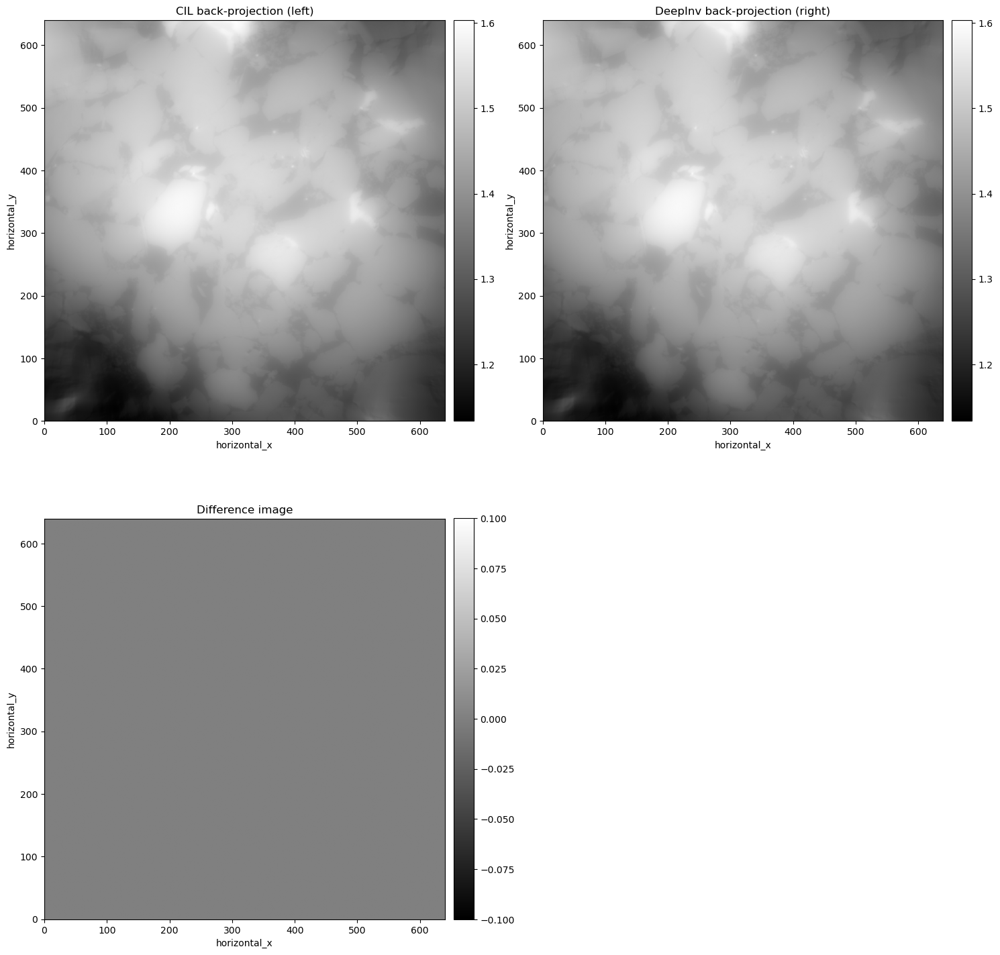

In [47]:

cil_astra_operator = ProjectionOperator(ig_binned, data_binned.geometry, device='gpu')
cil_back_proj = cil_astra_operator.adjoint(data_binned)/scaling 
processor_recon.set_input(cil_back_proj)
cil_back_proj = processor_recon.get_output()



back_prob = physics.A_adjoint(torch_data)
back_prob_deepinv = ig_binned.allocate(None)
back_prob_deepinv.array[:] = back_prob.squeeze(0).squeeze(0).detach().cpu().numpy()
processor_recon.set_input(back_prob_deepinv)
back_prob_deepinv = processor_recon.get_output()
show2D([back_prob_deepinv, cil_back_proj, back_prob_deepinv-cil_back_proj], title=["CIL back-projection (left)", "DeepInv back-projection (right)", "Difference image"])

In [48]:
from deepinv.models.base import Reconstructor
from tqdm import tqdm
from deepinv.loss.metric import PSNR


class DeepImagePrior(Reconstructor):
    r"""

    Deep Image Prior reconstruction.

    This method, introduced by :footcite:t:`ulyanov2018deep`, reconstructs an image by minimizing the loss function

    .. math::

        \min_{\theta}  \|y-AG_{\theta}(z)\|^2

    where :math:`z` is a random input and :math:`G_{\theta}` is a convolutional decoder network with parameters
    :math:`\theta`. The minimization should be stopped early to avoid overfitting. The method uses the Adam
    optimizer.

    .. note::

        This method only works with certain convolutional decoder networks. We recommend using the
        network :class:`deepinv.models.ConvDecoder`.


    .. note::

        The number of iterations and learning rate are set to the values used in the original paper. However, these
        values may not be optimal for all problems. We recommend experimenting with different values.

    :param torch.nn.Module generator: Convolutional decoder network.
    :param list, tuple img_size: Size `(C,H,W)` of the input noise vector :math:`z`.
    :param int iterations: Number of optimization iterations.
    :param float learning_rate: Learning rate of the Adam optimizer.
    :param bool verbose: If ``True``, print progress.
    :param bool re_init: If ``True``, re-initialize the network parameters before each reconstruction.
    """

    @_deprecated_alias(input_size="img_size")
    def __init__(
        self,
        generator: nn.Module,
        img_size: list[int] | tuple[int, ...],
        iterations: int = 2500,
        learning_rate: float = 1e-2,
        verbose: bool = False,
        re_init: bool = False,
    ):
        super().__init__()
        self.generator = generator
        self.max_iter = int(iterations)
        self.lr = learning_rate
        self.verbose = verbose
        self.re_init = re_init
        self.img_size = img_size

        from deepinv.loss.mc import MCLoss

        self.loss = MCLoss()
        self.psnr = PSNR()


    def forward(self, y: torch.Tensor, physics: Physics **kwargs) -> torch.Tensor:
        r"""
        Reconstruct an image from the measurement :math:`y`. The reconstruction is performed by solving a minimization
        problem.

        .. warning::

            The optimization is run for every test batch. Thus, this method can be slow when tested on a large
            number of test batches.

        :param torch.Tensor y: Measurement.
        :param torch.Tensor physics: Physics model.
        """
        save_error =[]
        if self.re_init:
            for layer in self.generator.children():
                if hasattr(layer, "reset_parameters"):
                    layer.reset_parameters()
        with torch.enable_grad():
            self.generator.requires_grad_(True)
            z = torch.randn(self.img_size, device=y.device).unsqueeze(0)
            optimizer = torch.optim.Adam(self.generator.parameters(), lr=self.lr)

            for it in tqdm(range(self.max_iter), disable=(not self.verbose)):
                x = self.generator(z)
                error = self.loss(y=y, x_net=x, physics=physics)
                save_error.append(error.cpu().detach().numpy())
                optimizer.zero_grad()
                error.backward()
                torch.nn.utils.clip_grad_norm_(self.generator.parameters(), max_norm=0.1)
                optimizer.step()

            return self.generator(z), save_error

In [49]:



iterations = 5000
lr = 0.001  # learning rate for the optimizer.
channels = 32  # number of channels per layer in the decoder.
in_size = [5,5] # size of the input to the decoder.
img_size = [1, ig_binned.shape[0], ig_binned.shape[1]]
backbone = dinv.models.ConvDecoder(
    img_size= img_size, in_size=in_size, channels=channels, layers=10
).to(device)





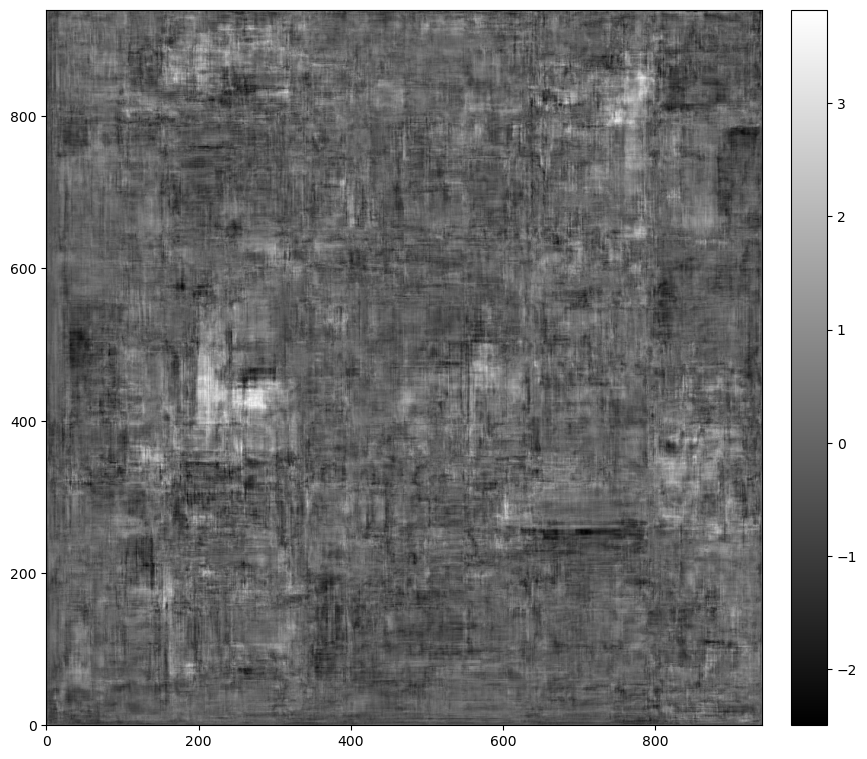

In [50]:
show2D(backbone(torch.randn([channels]+in_size, device=device).unsqueeze(0)).squeeze(0).squeeze(0).detach().cpu().numpy())

In [51]:

f = DeepImagePrior(
    backbone,
    learning_rate=lr,
    iterations=iterations,
    verbose=True,
    img_size=[channels] + in_size,
).to(device)



dip, save_error = f(torch_data, physics)

100%|██████████| 5000/5000 [03:19<00:00, 25.01it/s]


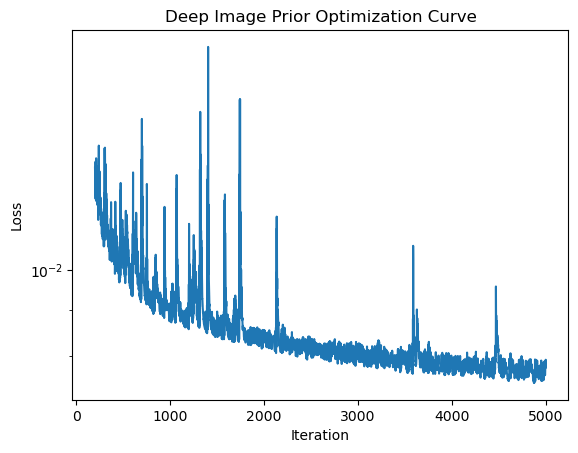

In [52]:
plt.figure()
plt.semilogy(range(200,iterations), save_error[200:])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Deep Image Prior Optimization Curve")
plt.show()


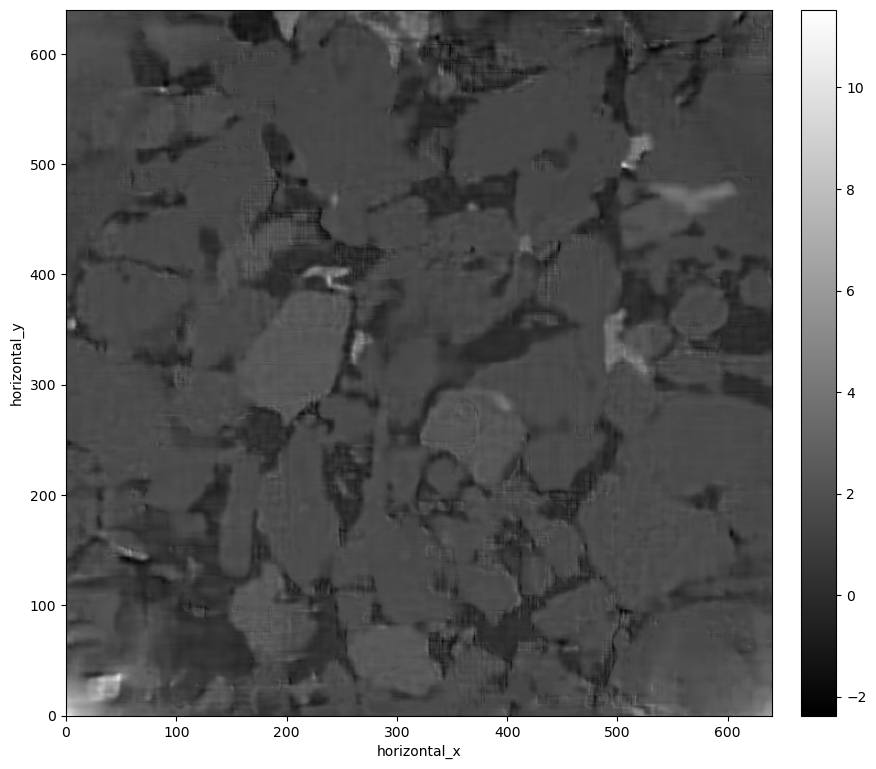

In [53]:
recon = ig_binned.allocate(None)

recon.array[:] = (dip.squeeze(0).squeeze(0)
                        .detach().cpu().numpy())

processor_recon.set_input(recon)
recon = processor_recon.get_output()

show2D(recon)

In [54]:

import torch
import neuralop

device = 'cuda'

H, W = 940, 940

# 1. Create a full coordinate grid of size 940x940
xs = torch.linspace(-1, 1, W)
ys = torch.linspace(-1, 1, H)
X, Y = torch.meshgrid(xs, ys, indexing='ij')

coord_grid = torch.stack([X, Y], dim=0)  # shape (2, H, W)
coord_grid = coord_grid.unsqueeze(0).to(device)  # shape (1,2,H,W)

print("coord grid:", coord_grid.shape)


model = neuralop.models.FNO((H, W),  2, 1, 16 ,
)



coord grid: torch.Size([1, 2, 940, 940])


output shape: torch.Size([1, 1, 940, 940])


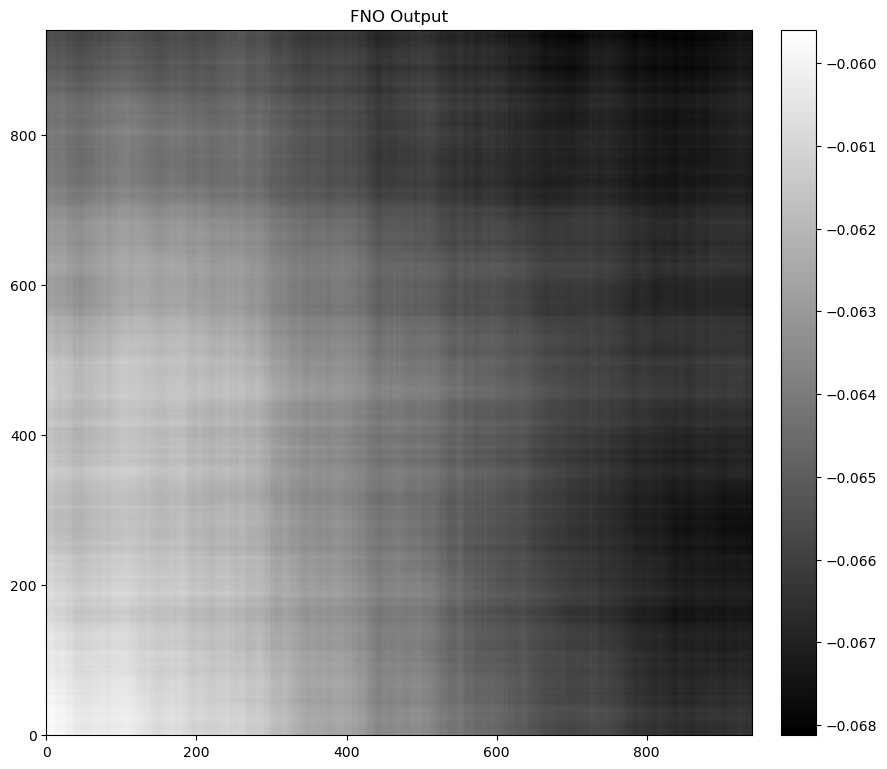

In [55]:
model = model.to(device)

output = model(coord_grid)

print("output shape:", output.shape)

show2D(output.squeeze(0).squeeze(0).detach().cpu().numpy(), title="FNO Output")

In [56]:
from deepinv.models.base import Reconstructor
from tqdm import tqdm

class DeepImagePriorINR(Reconstructor):
    r"""

    Deep Image Prior with implicit neural network 
    
    """
    

    @_deprecated_alias(input_size="img_size")
    def __init__(
        self,
        model: nn.Module,
        grid: torch.Tensor ,
        iterations: int = 2500,
        learning_rate: float = 1e-2,
        verbose: bool = False,
        re_init: bool = False,
    ):
        super().__init__()
        self.model = model
        self.max_iter = int(iterations)
        self.lr = learning_rate
        self.verbose = verbose
        self.re_init = re_init
        self.grid = grid

        from deepinv.loss.mc import MCLoss

        self.loss = MCLoss()


    def forward(self, y: torch.Tensor, physics: Physics, **kwargs) -> torch.Tensor:
        r"""
        Reconstruct an image from the measurement :math:`y`. The reconstruction is performed by solving a minimization
        problem.

        .. warning::

            The optimization is run for every test batch. Thus, this method can be slow when tested on a large
            number of test batches.

        :param torch.Tensor y: Measurement.
        :param torch.Tensor physics: Physics model.
        """
        save_error =[]
        if self.re_init:
            for layer in self.model.children():
                if hasattr(layer, "reset_parameters"):
                    layer.reset_parameters()
        with torch.enable_grad():
            self.model.requires_grad_(True)
            optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

            for it in tqdm(range(self.max_iter), disable=(not self.verbose)):
                x = self.model(self.grid)
                error = self.loss(y=y, x_net=x, physics=physics)
                save_error.append(error.cpu().detach().numpy())
                optimizer.zero_grad()
                error.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.1)
                optimizer.step()

            return self.model(self.grid), save_error

In [57]:
#Then build dip 
iterations=1000
f = DeepImagePriorINR(
    model,
    learning_rate=0.001,
    iterations= iterations,
    verbose=True,
    grid = coord_grid
).to(device)

dip, save_error = f(torch_data, physics)

100%|██████████| 1000/1000 [07:48<00:00,  2.13it/s]


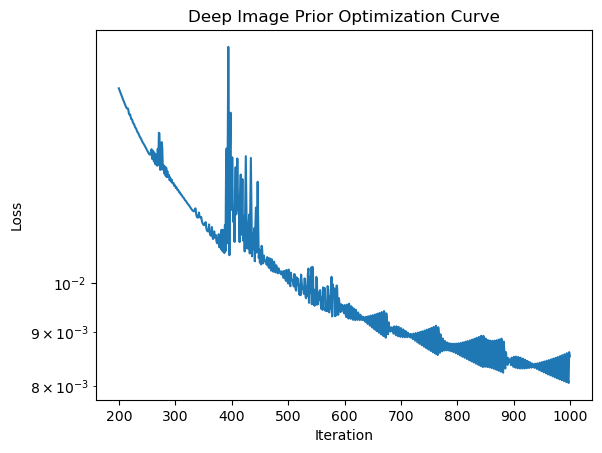

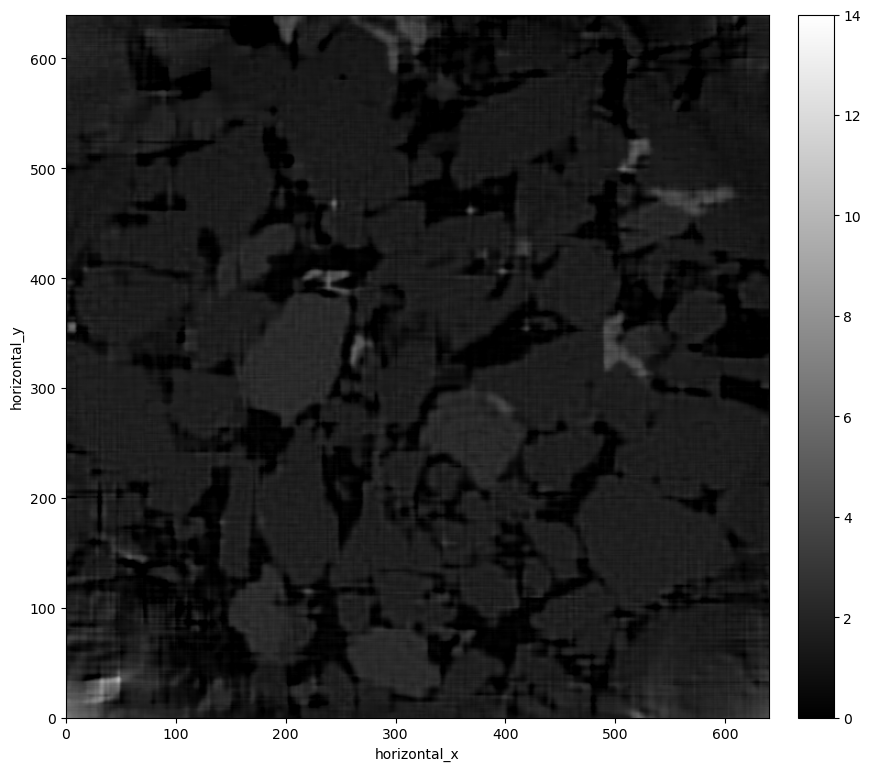

In [58]:
plt.semilogy(range(200,iterations), save_error[200:])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Deep Image Prior Optimization Curve")

recon_inr = ig_binned.allocate(None)

recon_inr.array[:] = (dip.squeeze(0).squeeze(0)
                        .detach().cpu().numpy())

processor_recon.set_input(recon_inr)
recon_inr = processor_recon.get_output()

show2D(recon_inr,  fix_range=(0,14))

TODO: 
    
    - Scalings are still broken between the reconstructions - can't compute quantitative comparisons
    - The INR DIP method is slow to compute and I should probably run for more iterations 
    - One of the benefits of the INR method should be that it is scalable to any size data. I wonder if it scalable to the full dataset? I don't quite understand why I need to pass the grid size to initialise it 
